In [4]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [14]:
problems = ["inverted_double_pendulum", "reacher", "swimmer", "hopper", "walker2d", "halfcheetah"]
seeds = range(0, 5)
algorithms = ["ga", "gomea"]
solvers = ["cgp", "lgp"]

dfs = []
for solver in solvers:
    for pop in ["small", "large"]:  #, "diverse"]:
        div = "_large_pop" if pop == "large" else ("_diversity" if pop == "diverse" else "")
        for algorithm in algorithms:
            for problem in problems:
                for seed in seeds:
                    if algorithm == "gomea":
                        for fos in ["U", "RT", "LT", ]:  # "LT1", "N1", "N2"]:
                            try:
                                tmp_df = pd.read_csv(
                                    f"../results/control/{algorithm}_{solver}_{problem}_{fos}_{seed}_fi{div}.csv")
                            except FileNotFoundError as e:
                                tmp_df = pd.read_csv(
                                    f"../results/control/{algorithm}_{solver}_{problem}_{fos}_{seed + 5}_fi{div}.csv")
                            tmp_df["seed"] = seed
                            tmp_df["pop"] = pop
                            tmp_df["algorithm"] = f"{algorithm}_{fos}"
                            tmp_df["problem"] = problem
                            tmp_df["solver"] = solver
                            dfs.append(tmp_df)
                    else:
                        if pop == "diverse":
                            continue
                        try:
                            tmp_df = pd.read_csv(f"../results/control/{algorithm}_{solver}_{problem}_{seed}{div}.csv")
                        except FileNotFoundError as e:
                            tmp_df = pd.read_csv(
                                f"../results/control/{algorithm}_{solver}_{problem}_{seed + 5}{div}.csv")
                        tmp_df["seed"] = seed
                        tmp_df["algorithm"] = algorithm
                        tmp_df["problem"] = problem
                        tmp_df["solver"] = solver
                        tmp_df["pop"] = pop
                        dfs.append(tmp_df)
control_df = pd.concat(dfs, ignore_index=True)
control_df.head()

,evaluation,fitness,uniqueness,time,seed,algorithm,problem,solver,pop
0,100,691.224609,1.0,20.86,0,ga,inverted_double_pendulum,cgp,small
1,190,691.224609,1.0,19.95,0,ga,inverted_double_pendulum,cgp,small
2,280,851.911133,1.0,6.65,0,ga,inverted_double_pendulum,cgp,small
3,370,889.655640,1.0,6.80,0,ga,inverted_double_pendulum,cgp,small
4,460,889.655640,1.0,6.81,0,ga,inverted_double_pendulum,cgp,small


In [3]:
rounding_factor = 1000
control_df["rounded_evaluation"] = (control_df["evaluation"] / rounding_factor).round() * rounding_factor

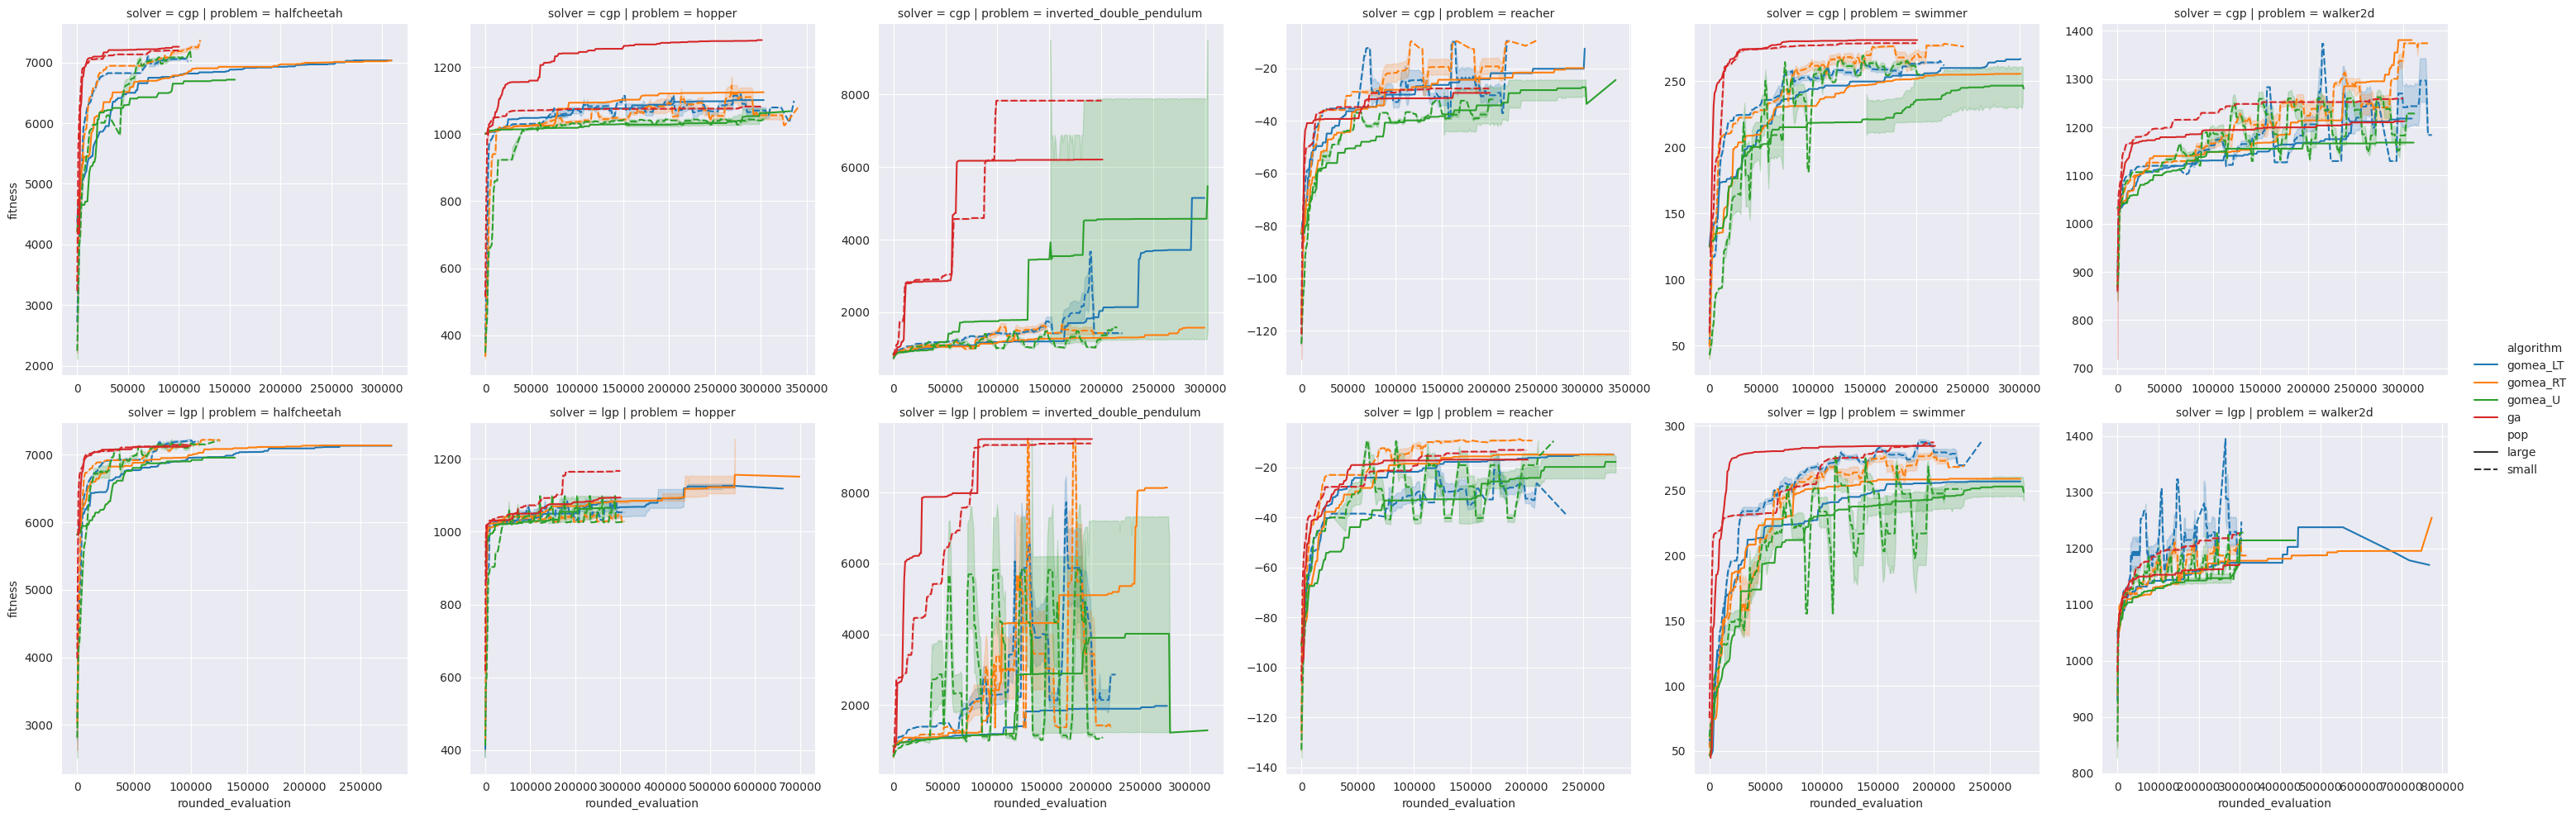

In [4]:
agg_df = (
    control_df
    .groupby(["rounded_evaluation", "evaluation", "problem", "algorithm", "solver", "pop"])
    .mean()
    .reset_index()
)
sns.relplot(
    data=agg_df,
    x="rounded_evaluation",
    y="fitness",
    style="pop",
    row="solver",
    col="problem",
    hue="algorithm",
    kind="line",
    facet_kws={'sharey': False, 'sharex': False}
)
plt.show()

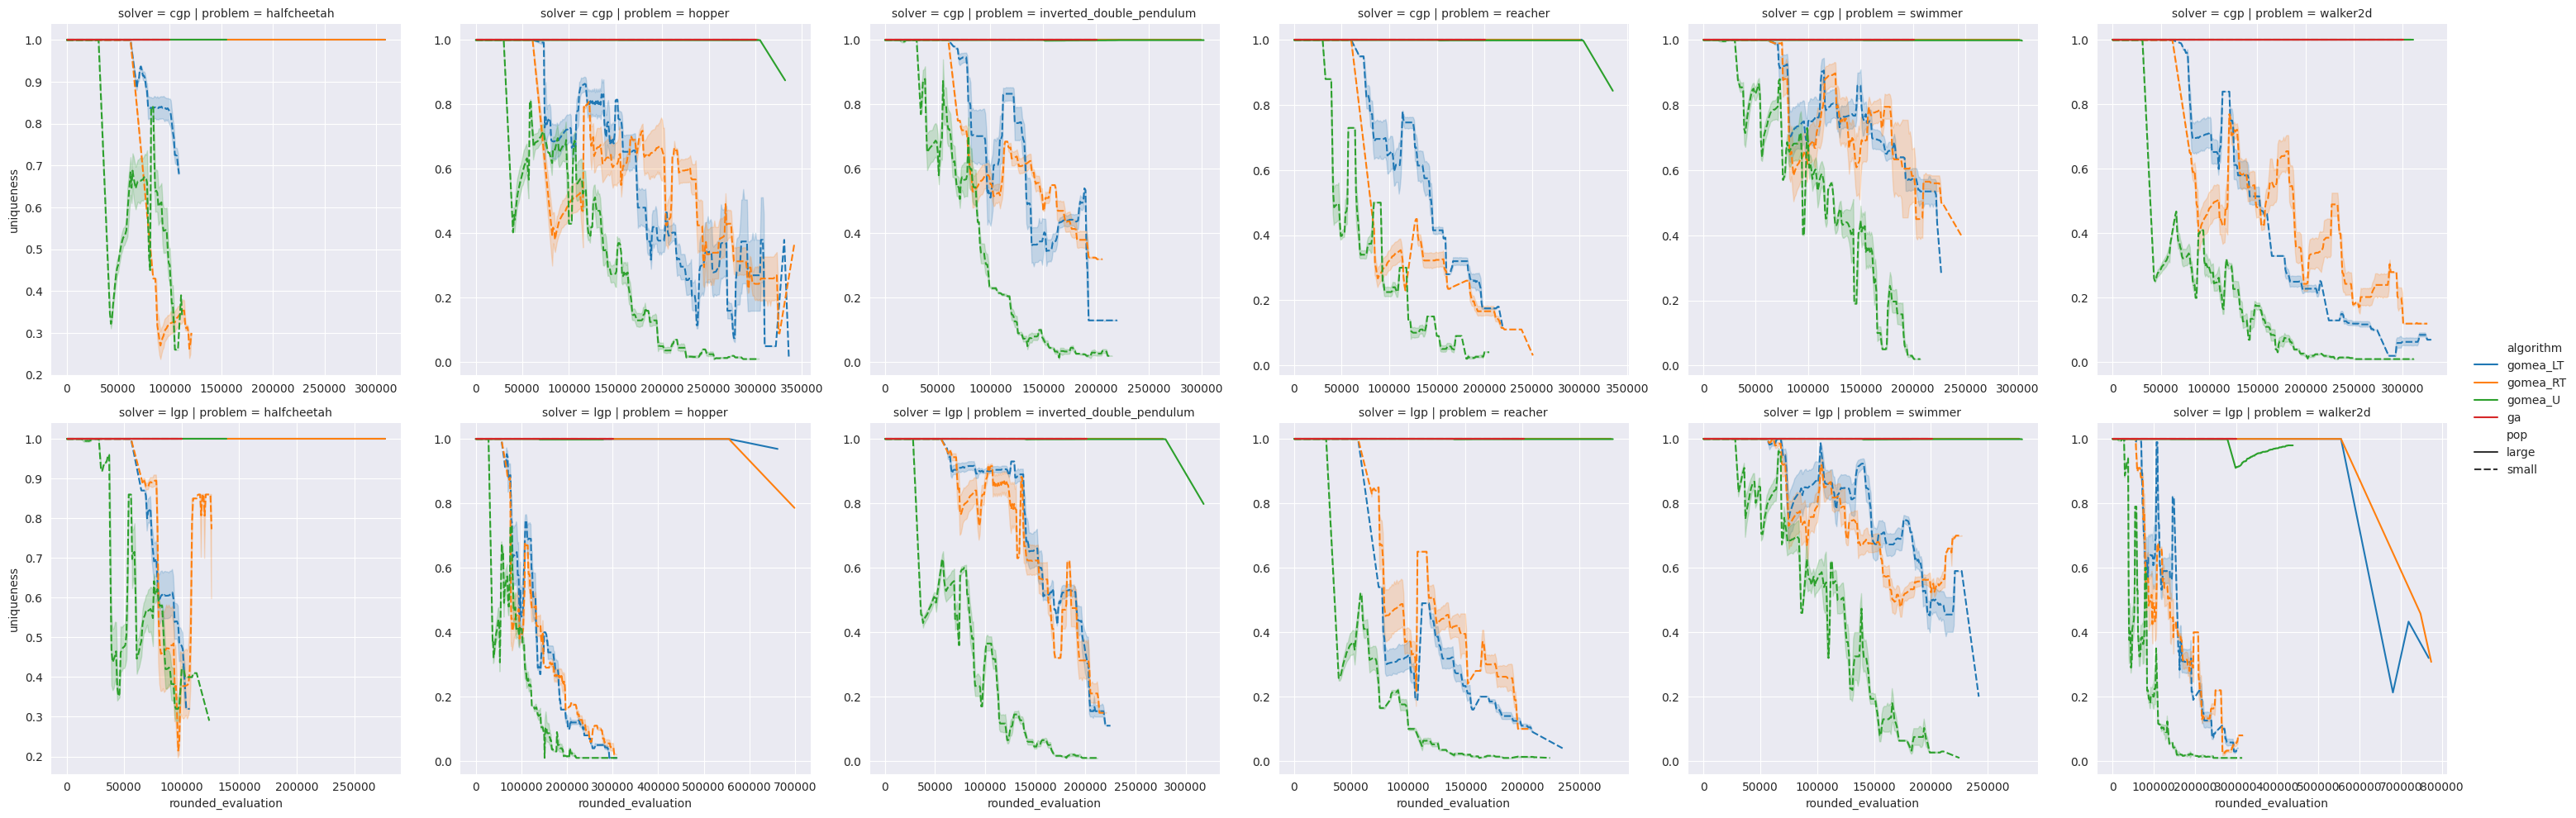

In [5]:
sns.relplot(
    agg_df,
    x="rounded_evaluation",
    y="uniqueness",
    style="pop",
    col="problem",
    row="solver",
    hue="algorithm",
    kind="line",
    facet_kws={'sharey': False, 'sharex': False}
)
plt.show()

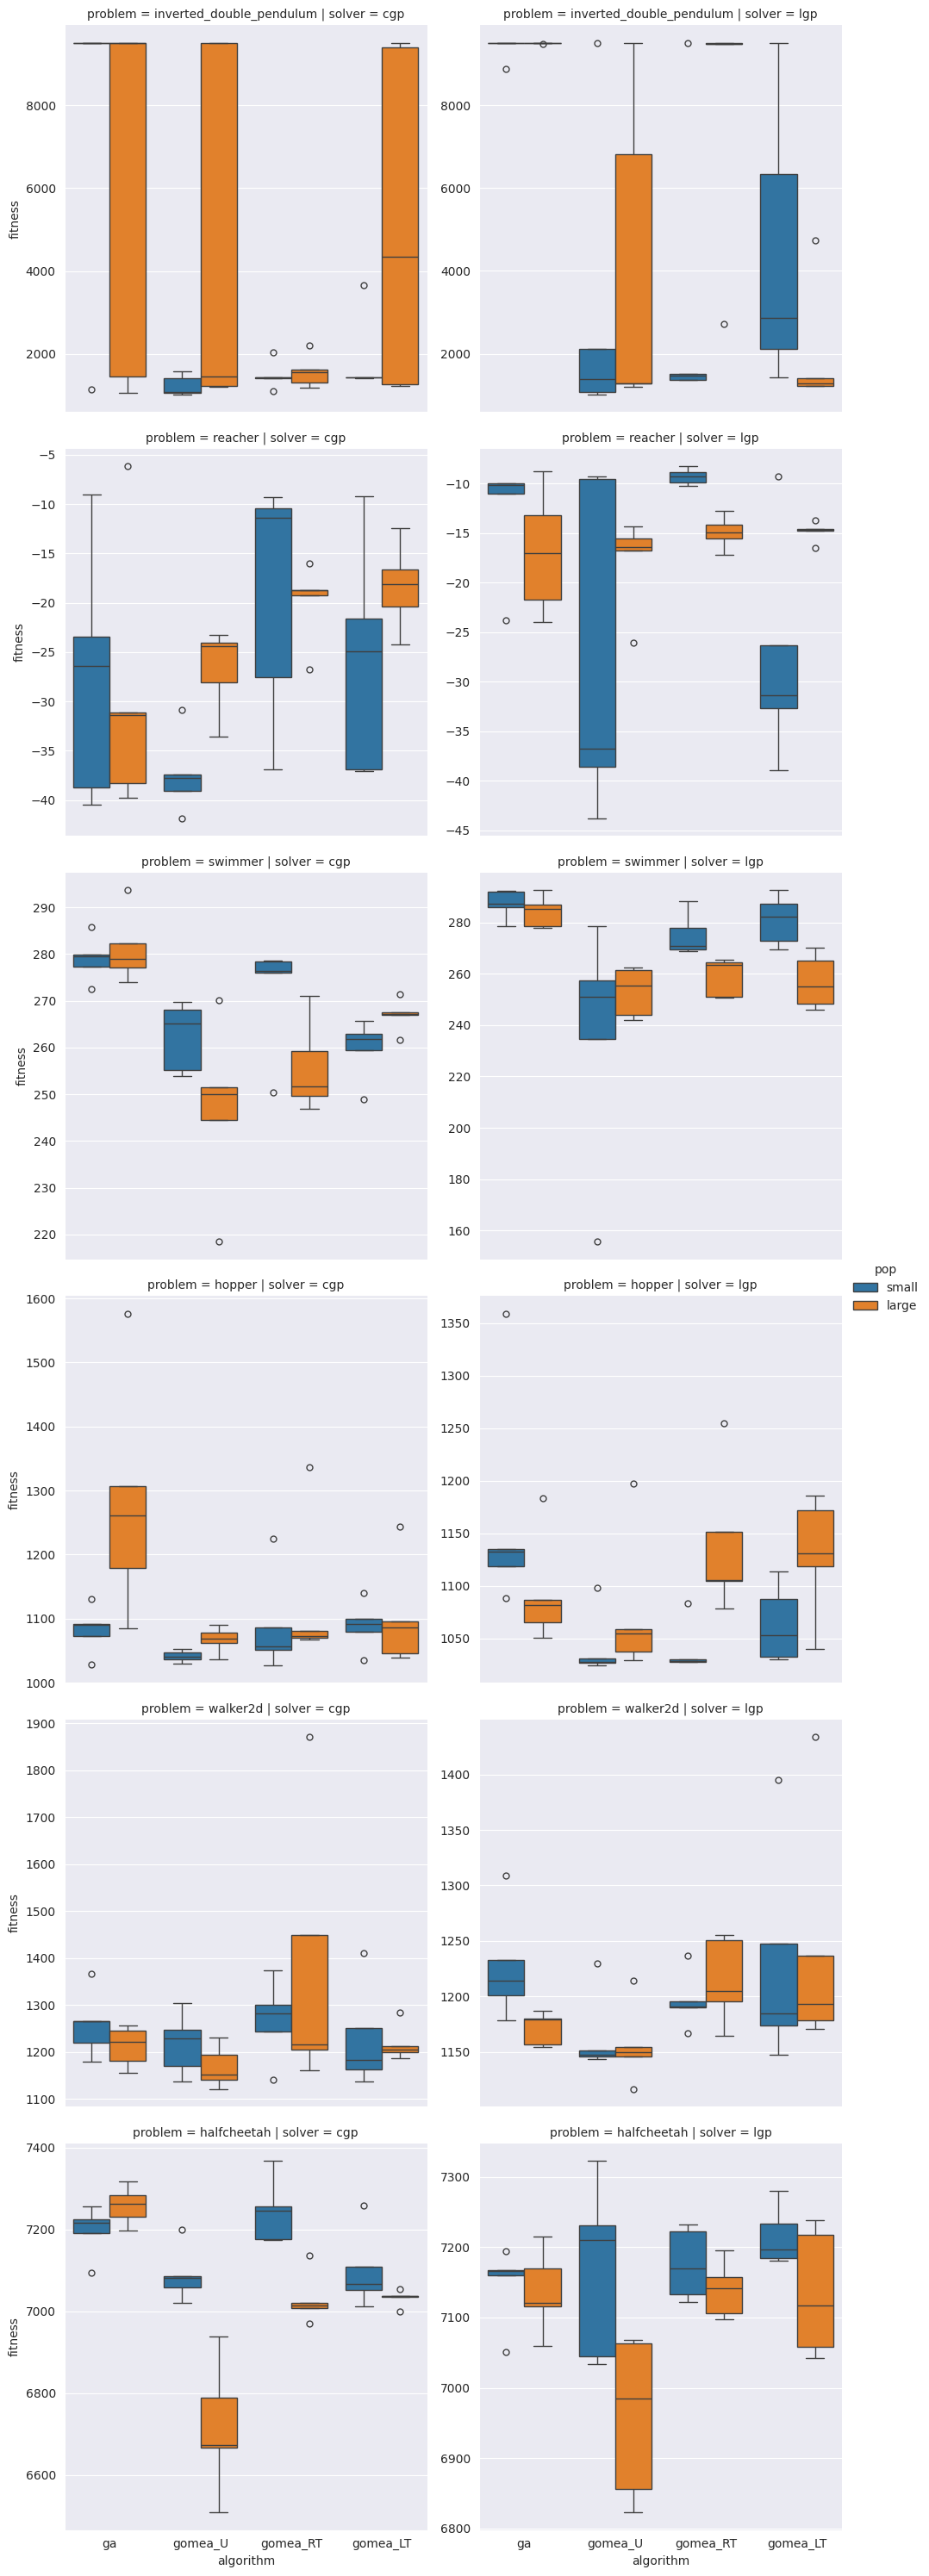

In [6]:
control_df["max_eval"] = control_df.groupby(["algorithm", "problem", "seed", "pop", "solver"])["evaluation"].transform(
    "max")
final_control_df = control_df[control_df["evaluation"] == control_df["max_eval"]].drop(columns="max_eval")
sns.catplot(
    data=final_control_df, x='algorithm', y='fitness', hue="pop", col="solver",
    row='problem', kind='box',
    sharey=False
)
plt.show()

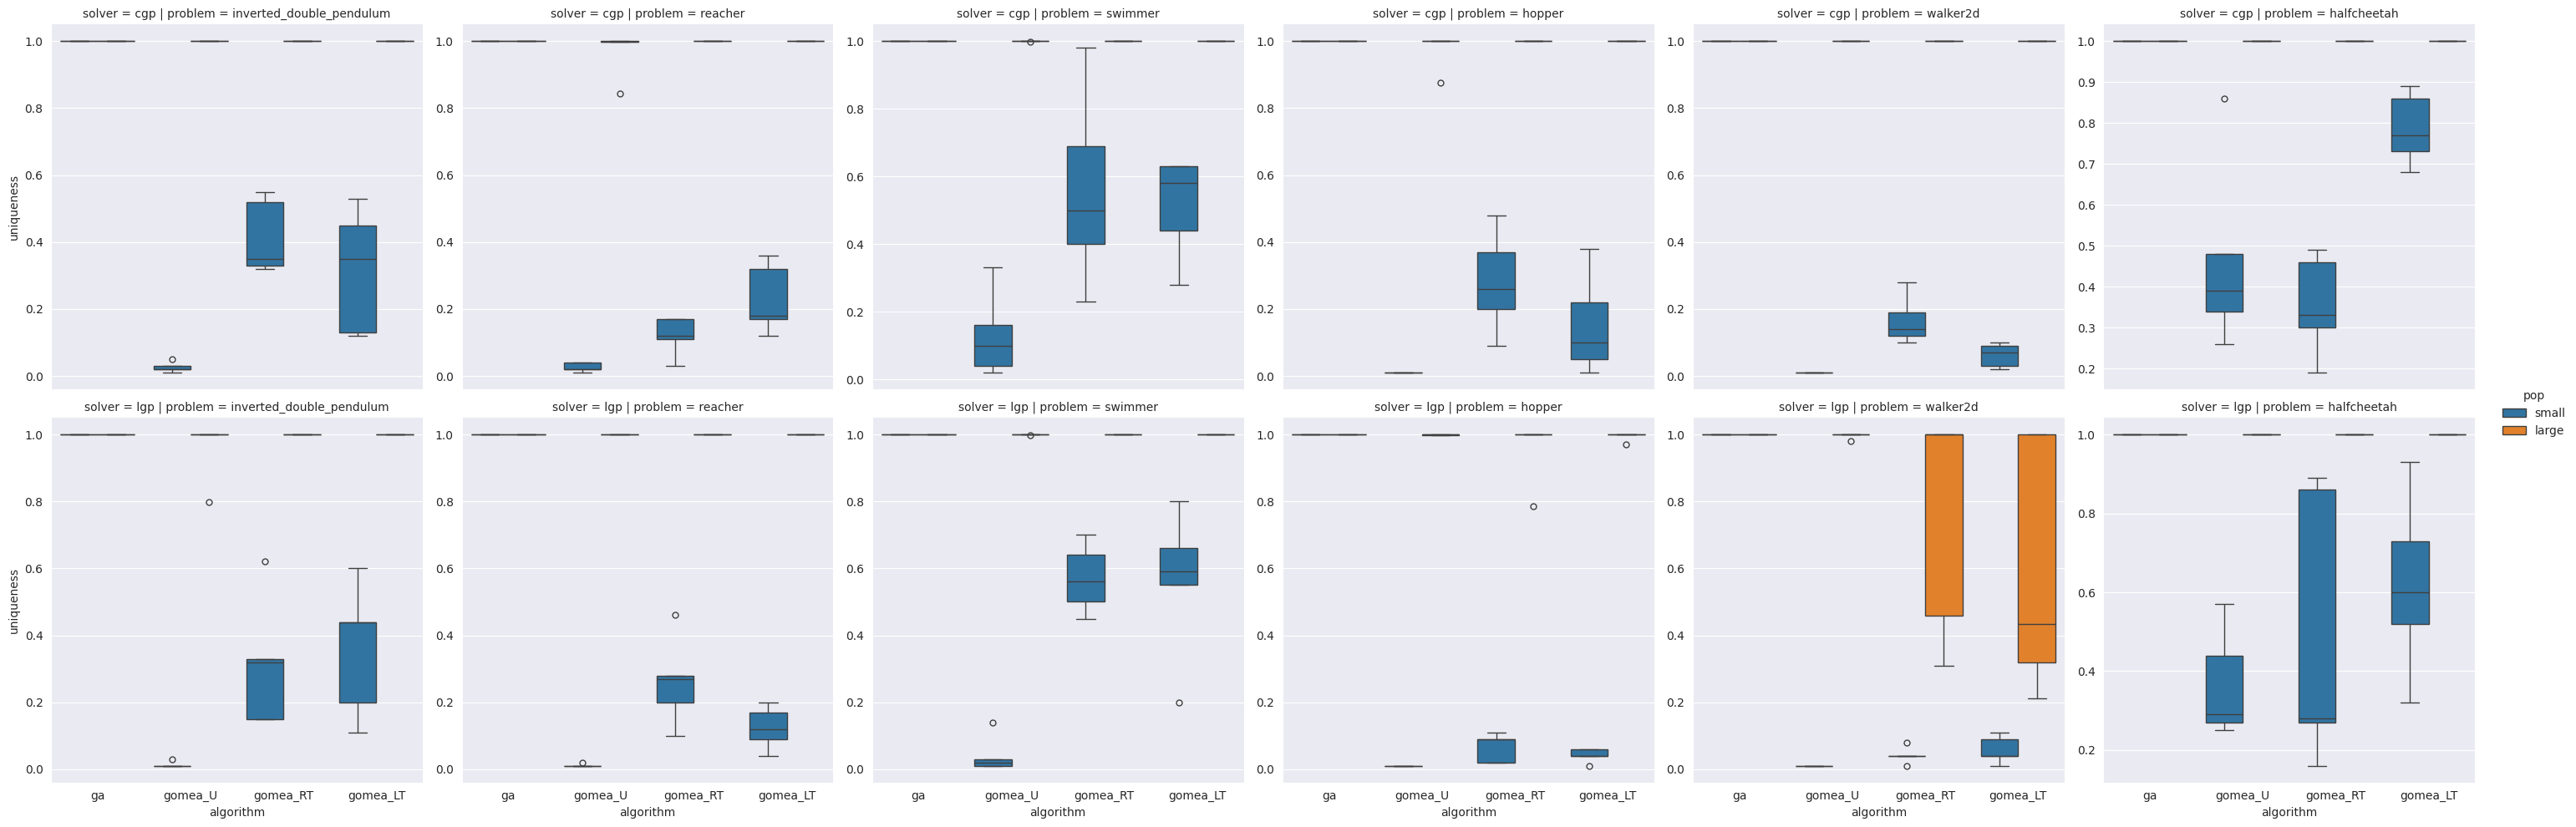

In [7]:
sns.catplot(
    data=final_control_df, x='algorithm', y='uniqueness', hue="pop",
    col='problem', kind='box', row="solver",
    sharey=False
)
plt.show()

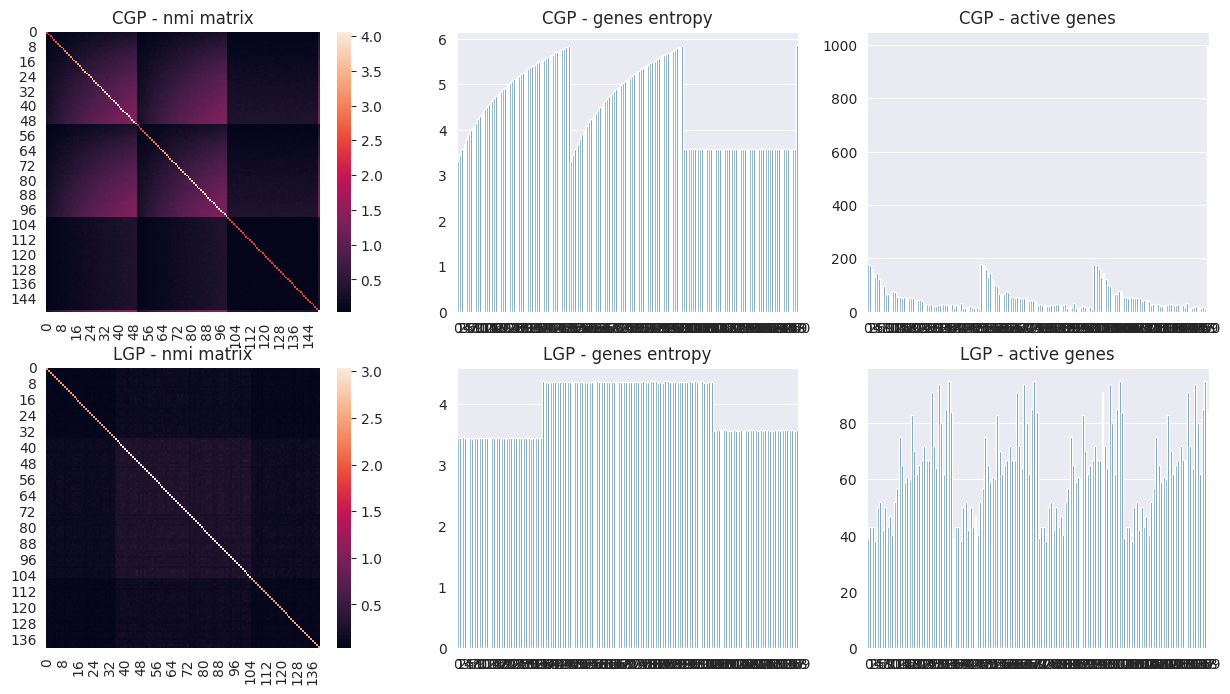

In [8]:
import jax.numpy as jnp

seed = 0
environment = "inverted_double_pendulum"
pop_type = "_large_pop"
solvers = ["cgp", "lgp"]

fig, axs = plt.subplots(2, 3)
fig.set_figwidth(15)
fig.set_figheight(8)

for solver_idx, solver in enumerate(solvers):
    base_path = f"../results/gomea_{solver}_{environment}_LT_{seed}_fi{pop_type}"
    nmi_matrix = jnp.load(f"{base_path}/nmi_matrix.npy")
    unique_genes = jnp.load(f"{base_path}/unique_genes.npy")
    activity_count = jnp.load(f"{base_path}/activity_count.npy")
    sns.heatmap(nmi_matrix, ax=axs[solver_idx, 0])
    axs[solver_idx, 0].set_title(f'{solver.upper()} - nmi matrix')
    sns.barplot(unique_genes, ax=axs[solver_idx, 1])
    axs[solver_idx, 1].set_title(f'{solver.upper()} - genes entropy')
    sns.barplot(activity_count, ax=axs[solver_idx, 2])
    axs[solver_idx, 2].set_title(f'{solver.upper()} - active genes')
plt.show()